# 05 — Análise por DDD

**Objetivo:** avaliar se o DDD do telefone é uma variável discriminatória para
identificar **Telefone HighRead** (taxa de leitura ≥ 75%). Para cada DDD,
estimamos `P(Telefone HighRead | DDD)` com intervalo de confiança de Wilson e
verificamos se há DDDs com concentração significativamente maior dessa
classe.

Trabalhamos a partir de `disparos_sistema.parquet`, gerado pelo
notebook `01_preprocessing.ipynb`.


**Definição adotada:**
- **Telefone HighRead**: telefone com taxa de leitura (`status == read`) ≥ **75%**.


## Roteiro
1. Construir métrica de **Telefone HighRead** por telefone (taxa de leitura ≥ 75%).
2. Estimar `P(Telefone HighRead | DDD)` com IC de Wilson para cada DDD.
3. Analisar a **distribuição de volume e incerteza** por DDD.
4. Filtrar DDDs com **estimativas confiáveis** (erro ≤ 10 %) e visualizar.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from statsmodels.stats.proportion import proportion_confint

OUT_DIR = Path('../outputs/processed')

df_disparos_sistema = pd.read_parquet(OUT_DIR / 'disparos_sistema.parquet')
print(f'df_disparos_sistema: {df_disparos_sistema.shape}')


df_disparos_sistema: (748675, 20)


## 1. Métrica de `Telefone HighRead`
Definimos como **Telefone HighRead** o telefone cuja taxa de leitura
(`status == read`) é ≥ 75 %. Agrupamos por `(telefone_numero, telefone_ddd)`
para associar cada telefone ao seu DDD.

In [2]:
LIMIAR_HIGH_READ = 0.75

df_tel_read = (
    df_disparos_sistema
    .assign(read=lambda x: (x['status_disparo'] == 'read').astype(int))
    .groupby(['telefone_numero',
              'telefone_ddd'])
    .agg(total_envios=('read', 'count'), reads=('read', 'sum'))
    .reset_index()
)
df_tel_read['taxa_read'] = df_tel_read['reads'] / df_tel_read['total_envios']
df_tel_read['high_read'] = (df_tel_read['taxa_read'] >= LIMIAR_HIGH_READ).astype(int)

df_tel_read.head()

,telefone_numero,telefone_ddd,total_envios,reads,taxa_read,high_read
0,10000135852850332451,17265310353192282774,6,6,1.0,1
1,10000156218966059013,17265310353192282774,2,2,1.0,1
2,10000201787338295860,17265310353192282774,1,1,1.0,1
3,10000226489572032674,17265310353192282774,2,2,1.0,1
4,10000343406836092322,17265310353192282774,2,0,0.0,0


## 2. Proporção de Telefone HighRead por DDD (IC de Wilson)
Para cada DDD estimamos `P(Telefone HighRead | DDD)` com intervalo de confiança
de Wilson.

In [3]:
def adiciona_ic_wilson(df: pd.DataFrame, count_col: str, total_col: str,
                       prefix: str = '') -> pd.DataFrame:
    """Adiciona colunas ci_low/ci_high a partir de contagens."""
    lows, highs = [], []
    for _, row in df.iterrows():
        low, high = proportion_confint(row[count_col], row[total_col], method='wilson')
        lows.append(low)
        highs.append(high)
    df[f'{prefix}ci_low'] = lows
    df[f'{prefix}ci_high'] = highs
    return df


df_ddd = (
    df_tel_read
    .groupby('telefone_ddd')
    .agg(qtd_telefones=('telefone_numero', 'nunique'),
         telefones_high_read=('high_read', 'sum'))
    .reset_index()
)
df_ddd['prob_high_read'] = df_ddd['telefones_high_read'] / df_ddd['qtd_telefones']
df_ddd = adiciona_ic_wilson(df_ddd, 'telefones_high_read', 'qtd_telefones')
df_ddd['erro'] = df_ddd['ci_high'] - df_ddd['prob_high_read']

print(f'Total de DDDs: {df_ddd.shape[0]}')

Total de DDDs: 67


## 3. Distribuição de volume e incerteza por DDD

In [4]:
df_ddd.sort_values(by='qtd_telefones', ascending=False).head(20)

,telefone_ddd,qtd_telefones,telefones_high_read,prob_high_read,ci_low,ci_high,erro
28,17265310353192282774,248973,179067,0.719223,0.717454,0.720984,0.001762
2,1110362451252208393,794,524,0.659950,0.626299,0.692060,0.032110
23,15846025020102267254,356,228,0.640449,0.589346,0.688554,0.048104
54,6906343888316397859,270,163,0.603704,0.544298,0.660199,0.056496
11,13922839047927264535,188,127,0.675532,0.605674,0.738360,0.062828
39,2685248380958544781,174,128,0.735632,0.665529,0.795556,0.059923
64,9525433826999338114,148,83,0.560811,0.480319,0.638225,0.077415
5,12707868701227488886,102,58,0.568627,0.471750,0.660524,0.091896
9,13185225668871621484,101,62,0.613861,0.516402,0.702977,0.089115
20,15468730639809407528,92,58,0.630435,0.528430,0.721984,0.091549


### 3.1. Volume de telefones por DDD

In [5]:
print("Menor volume:")
print(df_ddd.nsmallest(1, 'qtd_telefones')[['telefone_ddd', 'qtd_telefones']])

print("\nMaior volume:")
print(df_ddd.nlargest(1, 'qtd_telefones')[['telefone_ddd', 'qtd_telefones']])

Menor volume:
           telefone_ddd  qtd_telefones
42  3477629532570627175              2

Maior volume:
            telefone_ddd  qtd_telefones
28  17265310353192282774         248973


### 3.2. Distribuição do erro das estimativas

In [6]:
df_ddd['erro'].describe()

count    67.000000
mean      0.184447
std       0.097721
min       0.001762
25%       0.115400
50%       0.161318
75%       0.246621
max       0.459007
Name: erro, dtype: float64

> **Observação:** há grande discrepância no volume de dados entre os DDDs, o que impacta diretamente a confiabilidade das estimativas. A maioria apresenta erros elevados, como evidenciado pela distribuição do erro: média de 0.18, mediana de 0.16 e valores chegando a até 0.46. Diante disso, aplicaremos um filtro de erro máximo na próxima seção para garantir maior robustez nas análises.

## 4. DDDs com estimativas confiáveis (erro ≤ 10 %)
Filtramos apenas os DDDs cujo erro do IC de Wilson não excede 10 % para
garantir estimativas minimamente confiáveis.

DDDs após filtro: 12


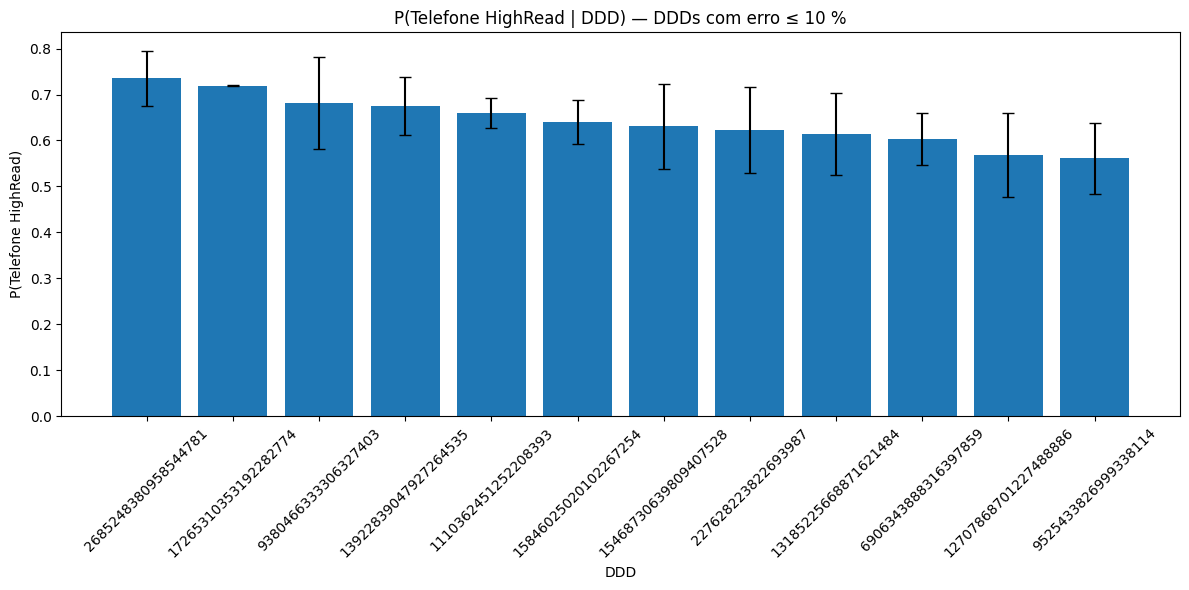

In [7]:
df_filtrado = df_ddd[df_ddd['erro'] <= 0.1].copy()
print(f"DDDs após filtro: {df_filtrado.shape[0]}")

df_filtrado = df_filtrado.sort_values('prob_high_read', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(
    df_filtrado['telefone_ddd'].astype(str),
    df_filtrado['prob_high_read'],
    yerr=df_filtrado['erro'],
    capsize=4
)
plt.xticks(rotation=45)
plt.xlabel('DDD')
plt.ylabel('P(Telefone HighRead)')
plt.title('P(Telefone HighRead | DDD) — DDDs com erro ≤ 10 %')
plt.tight_layout()
plt.show()

> Mesmo após a aplicação do filtro, os níveis de incerteza permanecem elevados, o que inviabiliza comparações robustas entre as proporções de **Telefone HighRead** entre DDDs.

## Conclusão

O DDD apresenta **baixo poder discriminatório** para identificar Telefone HighRead, com diferenças entre grupos pouco robustas devido à alta incerteza das estimativas. A mediana do erro é de aproximadamente 16%, indicando elevada variabilidade, especialmente em DDDs com menor volume de dados, o que reduz a confiabilidade dessa variável como critério de decisão.

**Implicação para o scoring:** o DDD não foi incluído como feature no algoritmo de escolha de telefones. 